# 19 -- QMKL-Boost : selection de kernels quantiques par QUBO

Hybridation de **QMKL** et **QBoost** : remplacer l'optimiseur MKL continu
(Centered Alignment, BO) par un **QUBO** qui selectionne un sous-ensemble
*sparse* et *divers* de kernels quantiques.

**Formulation** :

$$\min_{w \in \{0,1\}^M} \underbrace{-\sum_m w_m s_m}_{\text{performance}} + \lambda \underbrace{\sum_{m \neq m'} w_m w_{m'} A_{mm'}}_{\text{penalite de similitude}}$$

- $s_m$ = AUC CV-5 du kernel $m$ (score individuel)
- $A_{mm'}$ = alignement de Frobenius entre $K_m$ et $K_{m'}$ (similitude)
- $\lambda$ = parametre de diversite (0 = perf pure, grand = diversite pure)

**Connexion NB14** : $r=0.738$ diversite kernels $\leftrightarrow$ gain MKL.
Le QUBO encode cette intuition directement dans son objectif.

In [1]:
import sys, warnings, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import OrderedDict
warnings.filterwarnings('ignore')

ROOT = Path('.').resolve().parent
sys.path.insert(0, str(ROOT))

from data.loaders import load_dataset
from src.preprocessing import QuantumScaler, FeatureReducer
from src.mkl.alignment import centered_alignment
from qiskit.circuit.library import PauliFeatureMap
from qiskit.quantum_info import Statevector
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

OUT = ROOT / 'results' / '19'
OUT.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 130, 'font.size': 11, 'axes.titlesize': 13,
    'axes.spines.top': False, 'axes.spines.right': False,
    'savefig.bbox': 'tight',
})

N_SAMPLES = 150
Q         = 6
SEED      = 42
N_FOLDS   = 5
LAM_GRID  = np.concatenate([[0.0], np.linspace(0.05, 2.0, 20)])
LAM_EVAL  = [0.0, 0.25, 0.5, 1.0, 1.5, 2.0]

DATASETS = [
    ('german_credit',  'German Credit'),
    ('bank_marketing', 'Bank Marketing'),
    ('breast_cancer',  'Breast Cancer'),
]
print('Setup OK  N=%d  Q=%d  SEED=%d' % (N_SAMPLES, Q, SEED))

Setup OK  N=150  Q=6  SEED=42


---
## Fonctions utilitaires et bibliotheque de kernels

Trois familles de feature maps (Z, ZZ, XZ) x 4 valeurs d'alpha = **M=12 kernels**.
Cette structure garantit une haute similitude intra-famille et une plus faible inter-famille.
Le QUBO devra arbitrer entre choisir le meilleur alpha d'une famille
ou diversifier sur plusieurs familles.

In [2]:
# ----------------------------------------------------------------
# 12 kernels : 3 familles x 4 alphas
# ----------------------------------------------------------------
FM_LIBRARY = OrderedDict([
    ('Z a=1.0',  PauliFeatureMap(Q, reps=1, paulis=['Z'],      alpha=1.0, entanglement='linear')),
    ('Z a=2.0',  PauliFeatureMap(Q, reps=1, paulis=['Z'],      alpha=2.0, entanglement='linear')),
    ('Z a=3.0',  PauliFeatureMap(Q, reps=1, paulis=['Z'],      alpha=3.0, entanglement='linear')),
    ('Z a=4.0',  PauliFeatureMap(Q, reps=1, paulis=['Z'],      alpha=4.0, entanglement='linear')),
    ('ZZ a=0.5', PauliFeatureMap(Q, reps=1, paulis=['Z','ZZ'], alpha=0.5, entanglement='linear')),
    ('ZZ a=1.5', PauliFeatureMap(Q, reps=1, paulis=['Z','ZZ'], alpha=1.5, entanglement='linear')),
    ('ZZ a=2.5', PauliFeatureMap(Q, reps=1, paulis=['Z','ZZ'], alpha=2.5, entanglement='linear')),
    ('ZZ a=4.0', PauliFeatureMap(Q, reps=1, paulis=['Z','ZZ'], alpha=4.0, entanglement='linear')),
    ('XZ a=0.5', PauliFeatureMap(Q, reps=1, paulis=['X','Z'],  alpha=0.5, entanglement='linear')),
    ('XZ a=1.5', PauliFeatureMap(Q, reps=1, paulis=['X','Z'],  alpha=1.5, entanglement='linear')),
    ('XZ a=2.5', PauliFeatureMap(Q, reps=1, paulis=['X','Z'],  alpha=2.5, entanglement='linear')),
    ('XZ a=3.5', PauliFeatureMap(Q, reps=1, paulis=['X','Z'],  alpha=3.5, entanglement='linear')),
])
KNAMES = list(FM_LIBRARY.keys())
M      = len(FM_LIBRARY)

# ----------------------------------------------------------------
# Fonctions utilitaires
# ----------------------------------------------------------------
def fidelity_kernel(fm, X):
    params = list(fm.parameters)
    svs = np.array([
        Statevector.from_instruction(
            fm.assign_parameters({p: float(v) for p, v in zip(params, x)})
        ).data for x in X
    ])
    return np.abs(svs @ svs.conj().T) ** 2

def make_psd(K, eps=1e-8):
    lam = np.linalg.eigvalsh(K).min()
    return K + (abs(lam) + eps) * np.eye(K.shape[0]) if lam < 0 else K

def frob_align(K1, K2):
    num = np.sum(K1 * K2)
    den = np.linalg.norm(K1, 'fro') * np.linalg.norm(K2, 'fro') + 1e-24
    return float(num / den)

def cv_auc(K, y):
    skf  = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    aucs = []
    for tr, te in skf.split(K, y):
        clf = SVC(kernel='precomputed', probability=True, C=1.0)
        clf.fit(K[np.ix_(tr, tr)], y[tr])
        p = clf.predict_proba(K[np.ix_(te, tr)])[:, 1]
        try:    aucs.append(roc_auc_score(y[te], p))
        except: aucs.append(0.5)
    return float(np.mean(aucs))

def eval_w(K_list, w, y):
    idx = np.where(np.asarray(w) > 0.5)[0]
    if len(idx) == 0: return 0.0
    K = make_psd(np.mean([K_list[m] for m in idx], axis=0))
    return cv_auc(K, y)

def build_qubo(scores, A, lam):
    A_off = A - np.diag(np.diag(A))
    return np.diag(-scores) + lam * A_off

def qubo_bf(Q_mat):
    M_ = Q_mat.shape[0]
    best_obj, best_w = np.inf, np.ones(M_)
    for mask in range(1, 2**M_):
        w = np.array([(mask >> i) & 1 for i in range(M_)], dtype=float)
        obj = float(w @ Q_mat @ w)
        if obj < best_obj:
            best_obj, best_w = obj, w.copy()
    return best_w, best_obj

def qubo_sa(Q_mat, n_steps=6000, T_start=1.0, T_end=0.005, seed=SEED):
    rng = np.random.RandomState(seed)
    M_  = Q_mat.shape[0]
    w   = rng.randint(0, 2, M_).astype(float)
    E   = float(w @ Q_mat @ w)
    bw, bE = w.copy(), E
    temps = np.exp(np.linspace(np.log(T_start), np.log(T_end), n_steps))
    for T in temps:
        i  = rng.randint(M_)
        wn = w.copy(); wn[i] = 1 - wn[i]
        En = float(wn @ Q_mat @ wn)
        dE = En - E
        if dE < 0 or rng.rand() < np.exp(-dE / (T + 1e-12)):
            w, E = wn, En
            if E < bE: bw, bE = w.copy(), E
    return bw.astype(int)

FAMILY_COLORS = {'Z': '#2980b9', 'ZZ': '#e74c3c', 'XZ': '#27ae60'}
FAMILY_LABELS = ['Z']*4 + ['ZZ']*4 + ['XZ']*4

print('M=%d kernels | brute-force : %d sous-ensembles' % (M, 2**M - 1))
print('Familles : Z (x4), ZZ (x4), XZ (x4)')

M=12 kernels | brute-force : 4095 sous-ensembles
Familles : Z (x4), ZZ (x4), XZ (x4)


---
## Analyse 1 -- Metriques par kernel

Pour chaque dataset :
- Calcul des 12 matrices de Gram $K_m$ (fidelite quantique, statevector exact)
- AUC CV-5 individuelle $s_m$ (score QUBO diagonal)
- Matrice d'alignement de Frobenius $A_{mm'}$ (penalite QUBO hors-diagonale)


In [3]:
all_data   = {}
all_scores = {}
all_align  = {}

for ds_name, ds_label in DATASETS:
    t0 = time.time()
    X_raw, y = load_dataset(ds_name, n_samples=N_SAMPLES, random_state=SEED)
    reducer  = FeatureReducer(n_components=Q)
    scaler   = QuantumScaler(feature_range=(0, 2))
    X_q      = scaler.fit_transform(reducer.fit_transform(X_raw))

    K_list = [fidelity_kernel(fm, X_q) for fm in FM_LIBRARY.values()]
    scores = np.array([cv_auc(K, y) for K in K_list])

    A = np.zeros((M, M))
    for i in range(M):
        for j in range(M):
            A[i, j] = frob_align(K_list[i], K_list[j])

    all_data[ds_name]   = (X_q, y, K_list)
    all_scores[ds_name] = scores
    all_align[ds_name]  = A

    off = A[~np.eye(M, dtype=bool)]
    print('[%s] %.1fs  scores=%.3f-%.3f  align_off=%.3f-%.3f' % (
        ds_label, time.time()-t0, scores.min(), scores.max(),
        off.min(), off.max()))

print('Calcul termine.')

[German Credit] 2.5s  scores=0.553-0.793  align_off=0.259-0.975


[Bank Marketing] 2.7s  scores=0.347-0.767  align_off=0.272-0.977


[Breast Cancer] 2.6s  scores=0.914-0.992  align_off=0.305-0.988
Calcul termine.


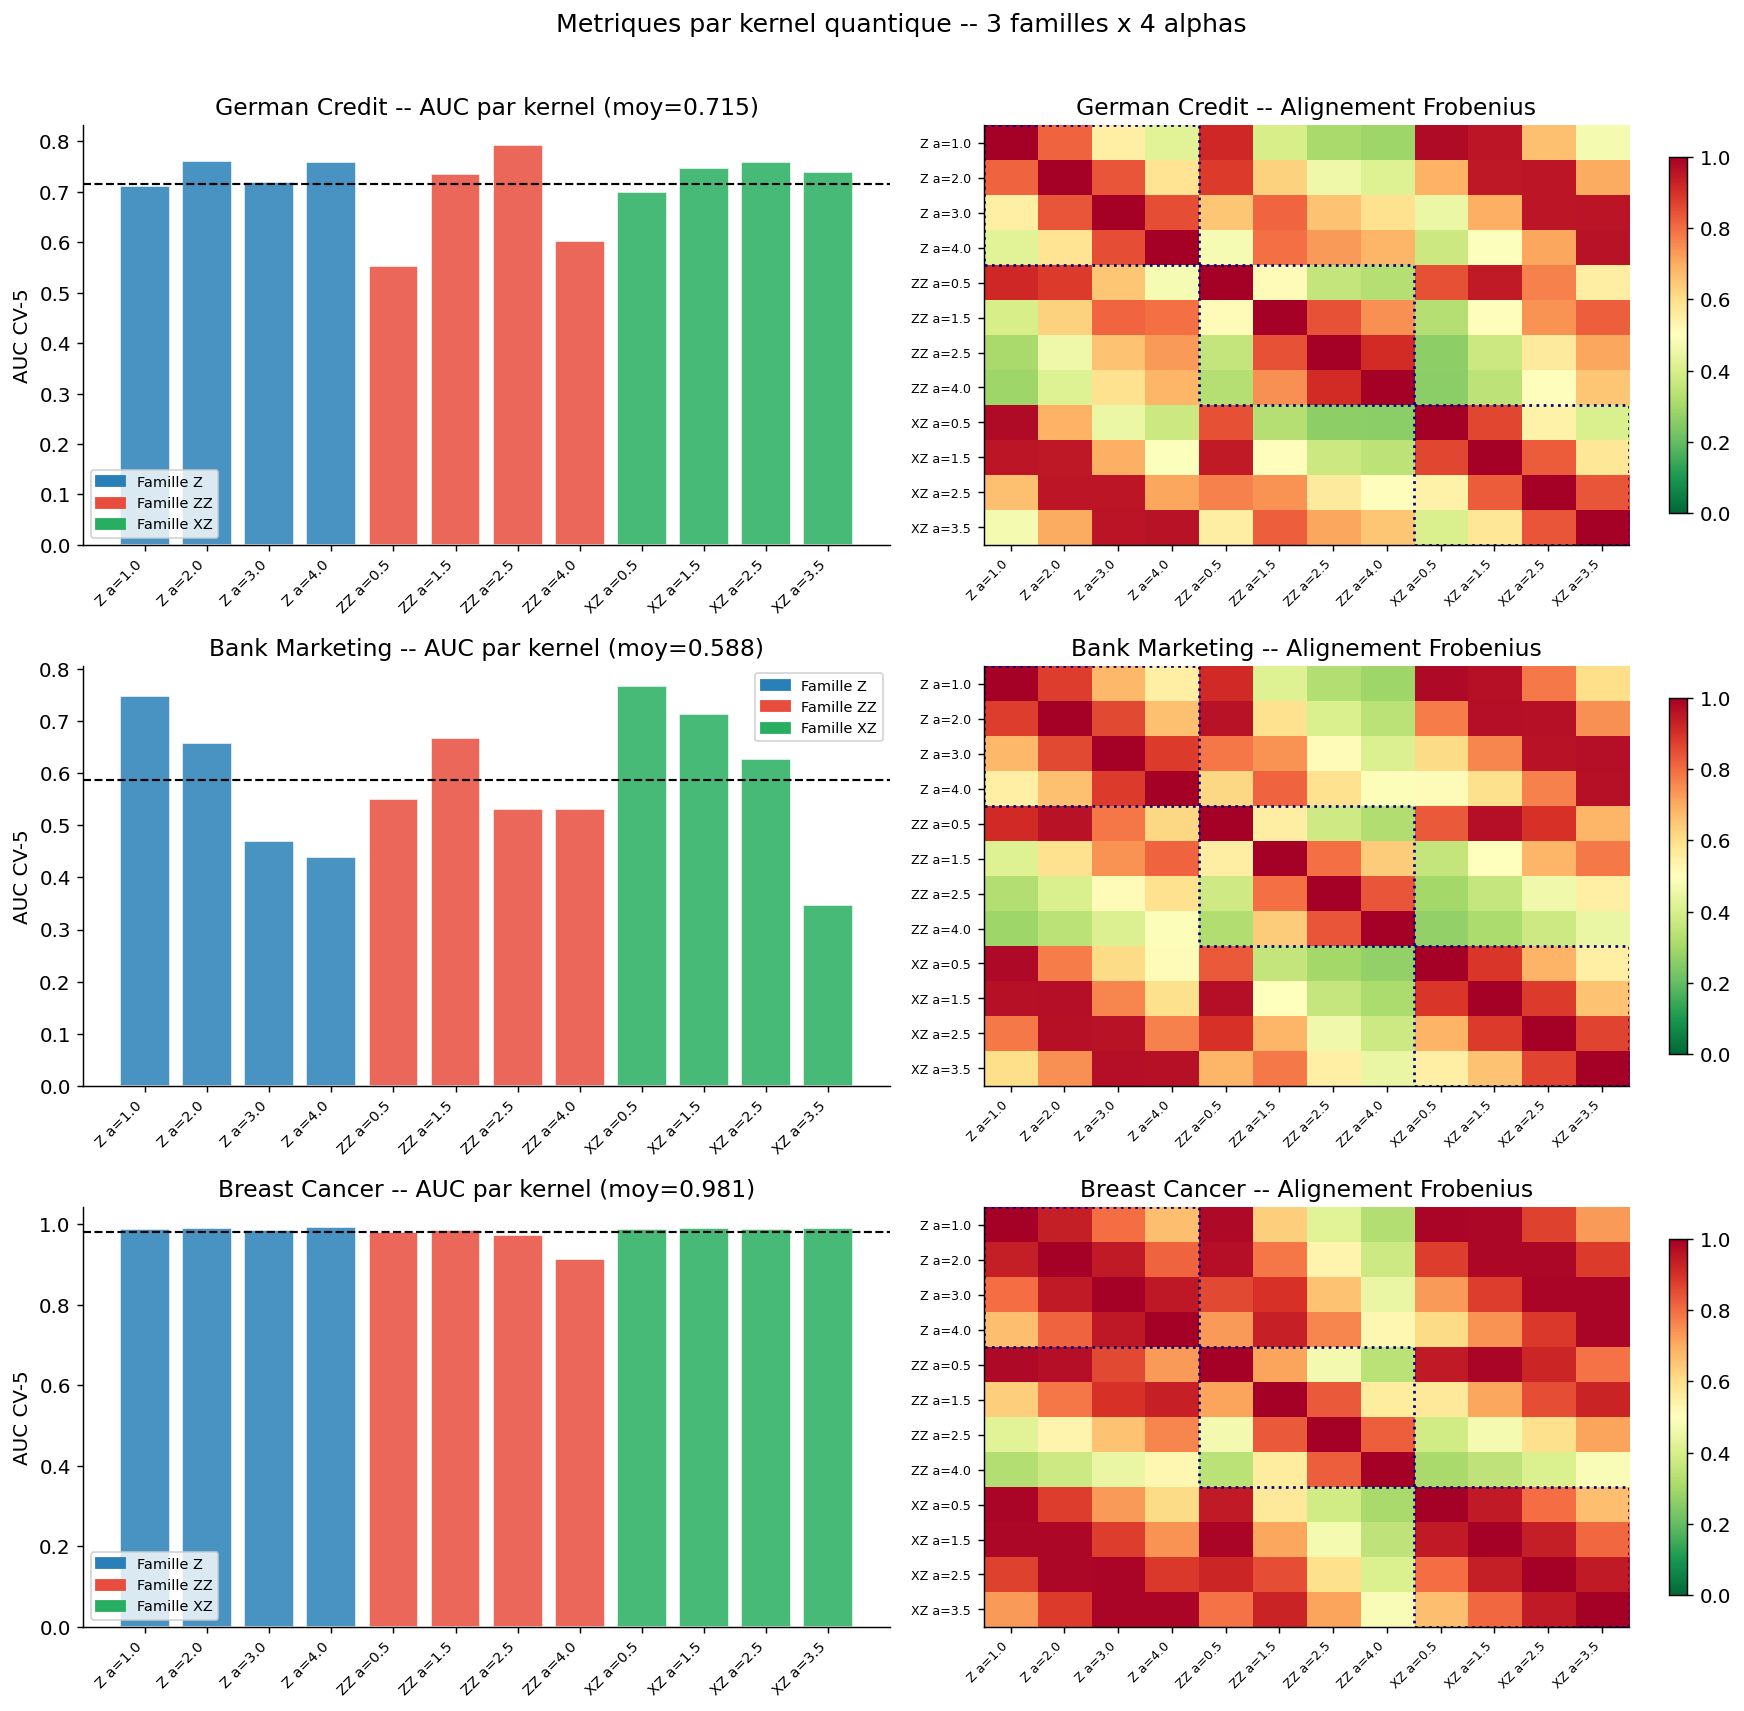

Figure 1 : 19_F1_kernel_metrics.png


In [4]:
fig, axes = plt.subplots(3, 2, figsize=(14, 13))
fig.suptitle('Metriques par kernel quantique -- 3 familles x 4 alphas', fontsize=14, y=1.01)

for row, (ds_name, ds_label) in enumerate(DATASETS):
    scores = all_scores[ds_name]
    A      = all_align[ds_name]

    # Barplot AUC
    ax = axes[row, 0]
    bar_colors = [FAMILY_COLORS[f] for f in FAMILY_LABELS]
    ax.bar(range(M), scores, color=bar_colors, alpha=0.85, edgecolor='white')
    ax.axhline(scores.mean(), ls='--', color='black', lw=1.2)
    ax.set_xticks(range(M))
    ax.set_xticklabels(KNAMES, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('AUC CV-5')
    ax.set_title('%s -- AUC par kernel (moy=%.3f)' % (ds_label, scores.mean()))
    patches = [mpatches.Patch(color=FAMILY_COLORS[f], label='Famille '+f)
               for f in ['Z','ZZ','XZ']]
    ax.legend(handles=patches, fontsize=8)

    # Heatmap alignement
    ax = axes[row, 1]
    im = ax.imshow(A, cmap='RdYlGn_r', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(M))
    ax.set_xticklabels(KNAMES, rotation=45, ha='right', fontsize=7)
    ax.set_yticks(range(M))
    ax.set_yticklabels(KNAMES, fontsize=7)
    ax.set_title('%s -- Alignement Frobenius' % ds_label)
    plt.colorbar(im, ax=ax, shrink=0.85)
    for start, end in [(0, 3), (4, 7), (8, 11)]:
        rect = plt.Rectangle((start-0.5, start-0.5), end-start+1, end-start+1,
                              fill=False, edgecolor='navy', lw=1.5, ls=':')
        ax.add_patch(rect)

plt.tight_layout()
plt.savefig(OUT / '19_F1_kernel_metrics.png', dpi=150)
plt.show()
print('Figure 1 : 19_F1_kernel_metrics.png')

---
## Analyse 2 -- Balayage de lambda : diversite vs performance

Pour chaque $\lambda \in [0, 2]$ :
1. Construction de la matrice QUBO : $Q_{mm} = -s_m$, $Q_{mm'} = \lambda A_{mm'}$ ($m \neq m'$)
2. Resolution par **brute-force** ($2^{12}-1 = 4095$ sous-ensembles, rapide)
3. Pour $\lambda \in \{0, 0.25, 0.5, 1.0, 1.5, 2.0\}$ : evaluation SVC CV-5

**Prediction** : un $\lambda^*$ optimal existe -- trop faible = kernels redondants,
trop fort = kernels sous-performants mais tres divers.

In [5]:
sweep_sel  = {}
sweep_nsel = {}
lambda_auc = {}

for ds_name, ds_label in DATASETS:
    _, y, K_list = all_data[ds_name]
    scores = all_scores[ds_name]
    A      = all_align[ds_name]

    sel_list, nsel_list = [], []
    for lam in LAM_GRID:
        Q_mat    = build_qubo(scores, A, lam)
        w_bf, _  = qubo_bf(Q_mat)
        sel_list.append(w_bf.copy())
        nsel_list.append(int(w_bf.sum()))

    sweep_sel[ds_name]  = sel_list
    sweep_nsel[ds_name] = nsel_list

    lam_res = {}
    for lam in LAM_EVAL:
        Q_mat    = build_qubo(scores, A, lam)
        w_bf, _  = qubo_bf(Q_mat)
        sel      = list(np.where(w_bf > 0.5)[0])
        auc      = eval_w(K_list, w_bf, y)
        lam_res[lam] = {'auc': auc, 'n_sel': int(w_bf.sum()), 'sel': sel}
    lambda_auc[ds_name] = lam_res

    best_l = max(lam_res, key=lambda l: lam_res[l]['auc'])
    print('[%s]  lambda*=%.2f  AUC*=%.4f  n_sel*=%d  kernels=%s' % (
        ds_label, best_l, lam_res[best_l]['auc'], lam_res[best_l]['n_sel'],
        [KNAMES[i] for i in lam_res[best_l]['sel']]))

print('Balayage lambda termine.')

[German Credit]  lambda*=1.00  AUC*=0.8238  n_sel*=2  kernels=['ZZ a=2.5', 'XZ a=0.5']


[Bank Marketing]  lambda*=1.00  AUC*=0.7669  n_sel*=1  kernels=['XZ a=0.5']


[Breast Cancer]  lambda*=0.00  AUC*=0.9923  n_sel*=12  kernels=['Z a=1.0', 'Z a=2.0', 'Z a=3.0', 'Z a=4.0', 'ZZ a=0.5', 'ZZ a=1.5', 'ZZ a=2.5', 'ZZ a=4.0', 'XZ a=0.5', 'XZ a=1.5', 'XZ a=2.5', 'XZ a=3.5']
Balayage lambda termine.


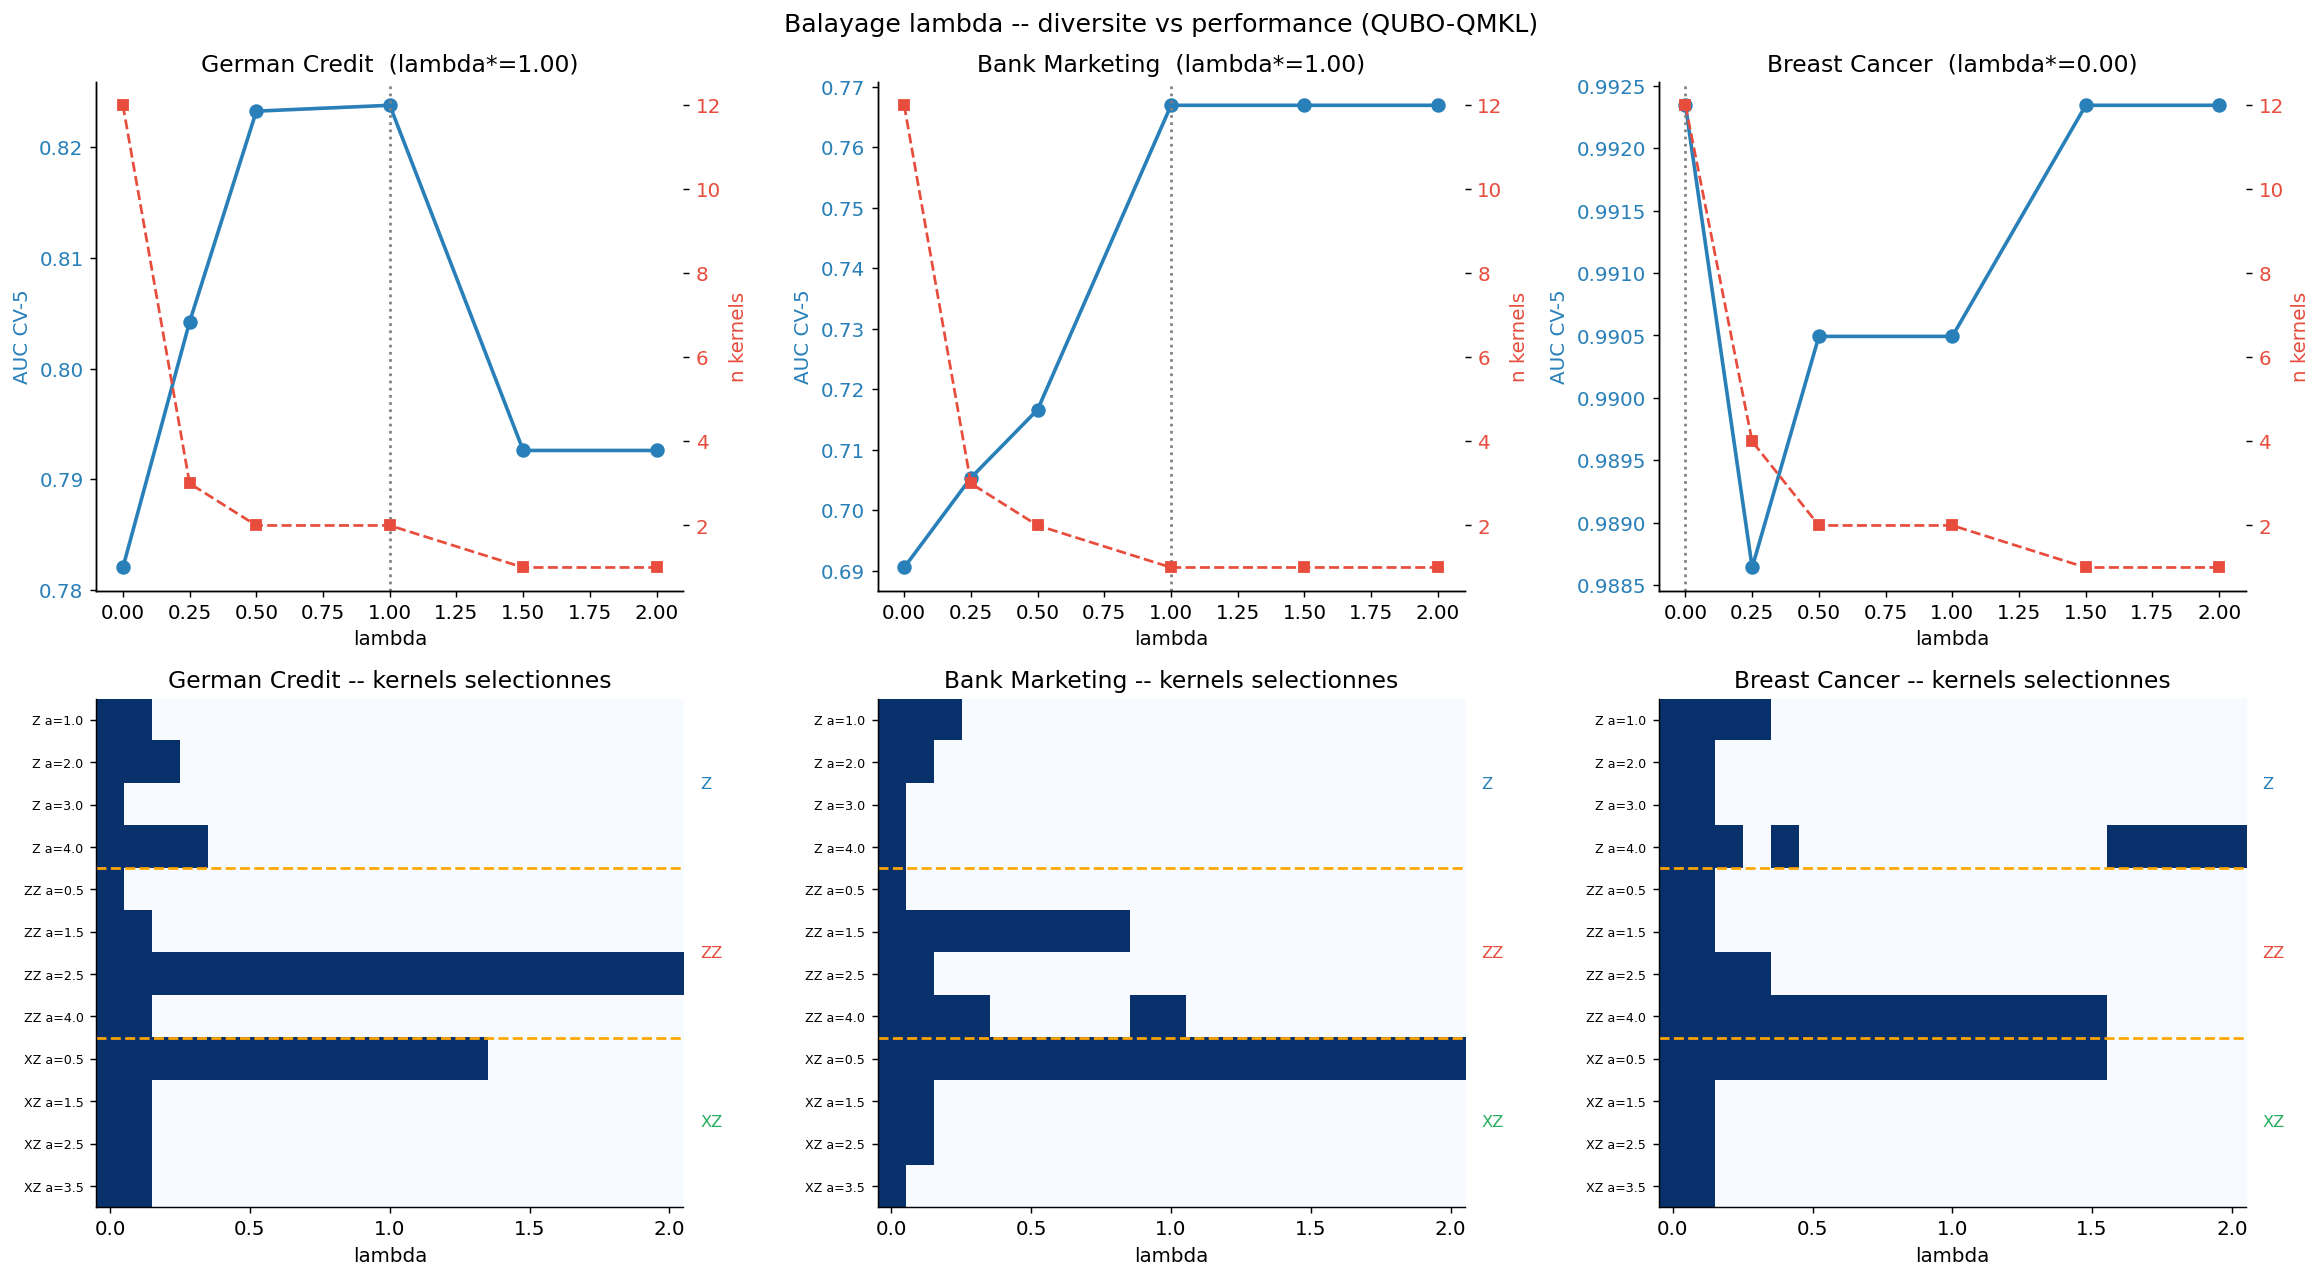

Figure 2 : 19_F2_lambda_sweep.png


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Balayage lambda -- diversite vs performance (QUBO-QMKL)', fontsize=14)

for col, (ds_name, ds_label) in enumerate(DATASETS):
    lam_res  = lambda_auc[ds_name]
    lam_keys = sorted(lam_res.keys())
    aucs_ev  = [lam_res[l]['auc']   for l in lam_keys]
    nsel_ev  = [lam_res[l]['n_sel'] for l in lam_keys]

    # Row 0 : AUC + n_selected vs lambda
    ax = axes[0, col]
    c_auc, c_n = '#2980b9', '#e74c3c'
    ax.plot(lam_keys, aucs_ev, 'o-', color=c_auc, lw=2, ms=7)
    ax.set_xlabel('lambda')
    ax.set_ylabel('AUC CV-5', color=c_auc)
    ax.tick_params(axis='y', labelcolor=c_auc)
    ax2 = ax.twinx()
    ax2.plot(lam_keys, nsel_ev, 's--', color=c_n, lw=1.5, ms=6)
    ax2.set_ylabel('n kernels', color=c_n)
    ax2.tick_params(axis='y', labelcolor=c_n)
    best_l = lam_keys[int(np.argmax(aucs_ev))]
    ax.axvline(best_l, ls=':', color='gray', lw=1.5)
    ax.set_title('%s  (lambda*=%.2f)' % (ds_label, best_l))

    # Row 1 : heatmap selection
    ax = axes[1, col]
    sel_mat = np.array(sweep_sel[ds_name]).T  # (M, n_lam)
    ax.imshow(sel_mat, aspect='auto', cmap='Blues', vmin=0, vmax=1,
              extent=[-0.5, len(LAM_GRID)-0.5, M-0.5, -0.5])
    ax.set_yticks(range(M))
    ax.set_yticklabels(KNAMES, fontsize=7)
    ticks_x = [0, len(LAM_GRID)//4, len(LAM_GRID)//2, 3*len(LAM_GRID)//4, len(LAM_GRID)-1]
    ax.set_xticks(ticks_x)
    ax.set_xticklabels(['%.1f' % LAM_GRID[t] for t in ticks_x])
    ax.set_xlabel('lambda')
    ax.set_title('%s -- kernels selectionnes' % ds_label)
    for sep in [3.5, 7.5]:
        ax.axhline(sep, color='orange', lw=1.5, ls='--')
    for y_pos, fname in zip([1.5, 5.5, 9.5], ['Z', 'ZZ', 'XZ']):
        ax.text(len(LAM_GRID)+0.1, y_pos, fname, fontsize=9,
                va='center', color=FAMILY_COLORS[fname])

plt.tight_layout()
plt.savefig(OUT / '19_F2_lambda_sweep.png', dpi=150)
plt.show()
print('Figure 2 : 19_F2_lambda_sweep.png')

---
## Analyse 3 -- Comparaison globale des strategies MKL

| Methode | Poids | Sparsite |
|---------|-------|----------|
| Average | $w_m = 1/M$ | Dense (M=12) |
| Centered Alignment | Continus $w_m \geq 0$ | Semi-sparse |
| QUBO-SA | Binaires $\{0,1\}$ | Sparse (recuit simule, proxy QPU) |
| QUBO-BF | Binaires $\{0,1\}$ | Sparse (brute-force, optimal) |
| Single-Best | $w_{m^*}=1$ | Ultra-sparse (k=1) |

Le lambda optimal est le lambda* identifie par le balayage (maximise AUC CV-5).

In [7]:
METHODS_ORDER = ['Average', 'Centered', 'QUBO-SA', 'QUBO-BF', 'Single-Best']
METHOD_COLORS = {
    'Average':     '#95a5a6',
    'Centered':    '#8e44ad',
    'QUBO-SA':     '#e67e22',
    'QUBO-BF':     '#e74c3c',
    'Single-Best': '#2980b9',
}

comparison = {}

for ds_name, ds_label in DATASETS:
    _, y, K_list = all_data[ds_name]
    scores = all_scores[ds_name]
    A      = all_align[ds_name]
    Kt     = (y[:, None] == y[None, :]).astype(float)

    lam_res  = lambda_auc[ds_name]
    lam_star = max(lam_res, key=lambda l: lam_res[l]['auc'])
    Q_star   = build_qubo(scores, A, lam_star)

    ds_comp = {}

    # 1. Average
    ds_comp['Average'] = {'auc': eval_w(K_list, np.ones(M), y), 'n_sel': M}

    # 2. Centered Alignment
    w_ca = centered_alignment(K_list, Kt)
    w_ca = np.maximum(w_ca, 0); w_ca /= (w_ca.sum() + 1e-12)
    K_ca = make_psd(sum(w_ca[m] * K_list[m] for m in range(M)))
    ds_comp['Centered'] = {'auc': cv_auc(K_ca, y), 'n_sel': int((w_ca > 1e-4).sum())}

    # 3. QUBO-SA
    w_sa = qubo_sa(Q_star)
    ds_comp['QUBO-SA'] = {
        'auc': eval_w(K_list, w_sa, y),
        'n_sel': int(w_sa.sum()),
        'sel': list(np.where(w_sa > 0.5)[0])
    }

    # 4. QUBO-BF
    w_bf, _ = qubo_bf(Q_star)
    ds_comp['QUBO-BF'] = {
        'auc': eval_w(K_list, w_bf, y),
        'n_sel': int(w_bf.sum()),
        'sel': list(np.where(w_bf > 0.5)[0])
    }

    # 5. Single Best
    best_m = int(np.argmax(scores))
    w_sb   = np.zeros(M); w_sb[best_m] = 1.0
    ds_comp['Single-Best'] = {'auc': float(scores[best_m]), 'n_sel': 1, 'sel': [best_m]}

    comparison[ds_name] = ds_comp
    print('[%s]  lambda*=%.2f' % (ds_label, lam_star))
    for meth in METHODS_ORDER:
        r = ds_comp[meth]
        sel = [KNAMES[i] for i in r.get('sel', [])] if 'sel' in r else []
        print('  %-14s: AUC=%.4f  n_sel=%2d  %s' % (meth, r['auc'], r['n_sel'], sel))

print('Comparaison terminee.')

[German Credit]  lambda*=1.00
  Average       : AUC=0.7820  n_sel=12  []
  Centered      : AUC=0.7989  n_sel= 5  []
  QUBO-SA       : AUC=0.8233  n_sel= 2  ['ZZ a=2.5', 'XZ a=0.5']
  QUBO-BF       : AUC=0.8233  n_sel= 2  ['ZZ a=2.5', 'XZ a=0.5']
  Single-Best   : AUC=0.7926  n_sel= 1  ['ZZ a=2.5']
[Bank Marketing]  lambda*=1.00
  Average       : AUC=0.6906  n_sel=12  []
  Centered      : AUC=0.7304  n_sel= 3  []
  QUBO-SA       : AUC=0.7669  n_sel= 1  ['XZ a=0.5']
  QUBO-BF       : AUC=0.7669  n_sel= 1  ['XZ a=0.5']
  Single-Best   : AUC=0.7669  n_sel= 1  ['XZ a=0.5']


[Breast Cancer]  lambda*=0.00
  Average       : AUC=0.9923  n_sel=12  []
  Centered      : AUC=0.9924  n_sel= 3  []
  QUBO-SA       : AUC=0.9923  n_sel=12  ['Z a=1.0', 'Z a=2.0', 'Z a=3.0', 'Z a=4.0', 'ZZ a=0.5', 'ZZ a=1.5', 'ZZ a=2.5', 'ZZ a=4.0', 'XZ a=0.5', 'XZ a=1.5', 'XZ a=2.5', 'XZ a=3.5']
  QUBO-BF       : AUC=0.9923  n_sel=12  ['Z a=1.0', 'Z a=2.0', 'Z a=3.0', 'Z a=4.0', 'ZZ a=0.5', 'ZZ a=1.5', 'ZZ a=2.5', 'ZZ a=4.0', 'XZ a=0.5', 'XZ a=1.5', 'XZ a=2.5', 'XZ a=3.5']
  Single-Best   : AUC=0.9923  n_sel= 1  ['Z a=4.0']
Comparaison terminee.


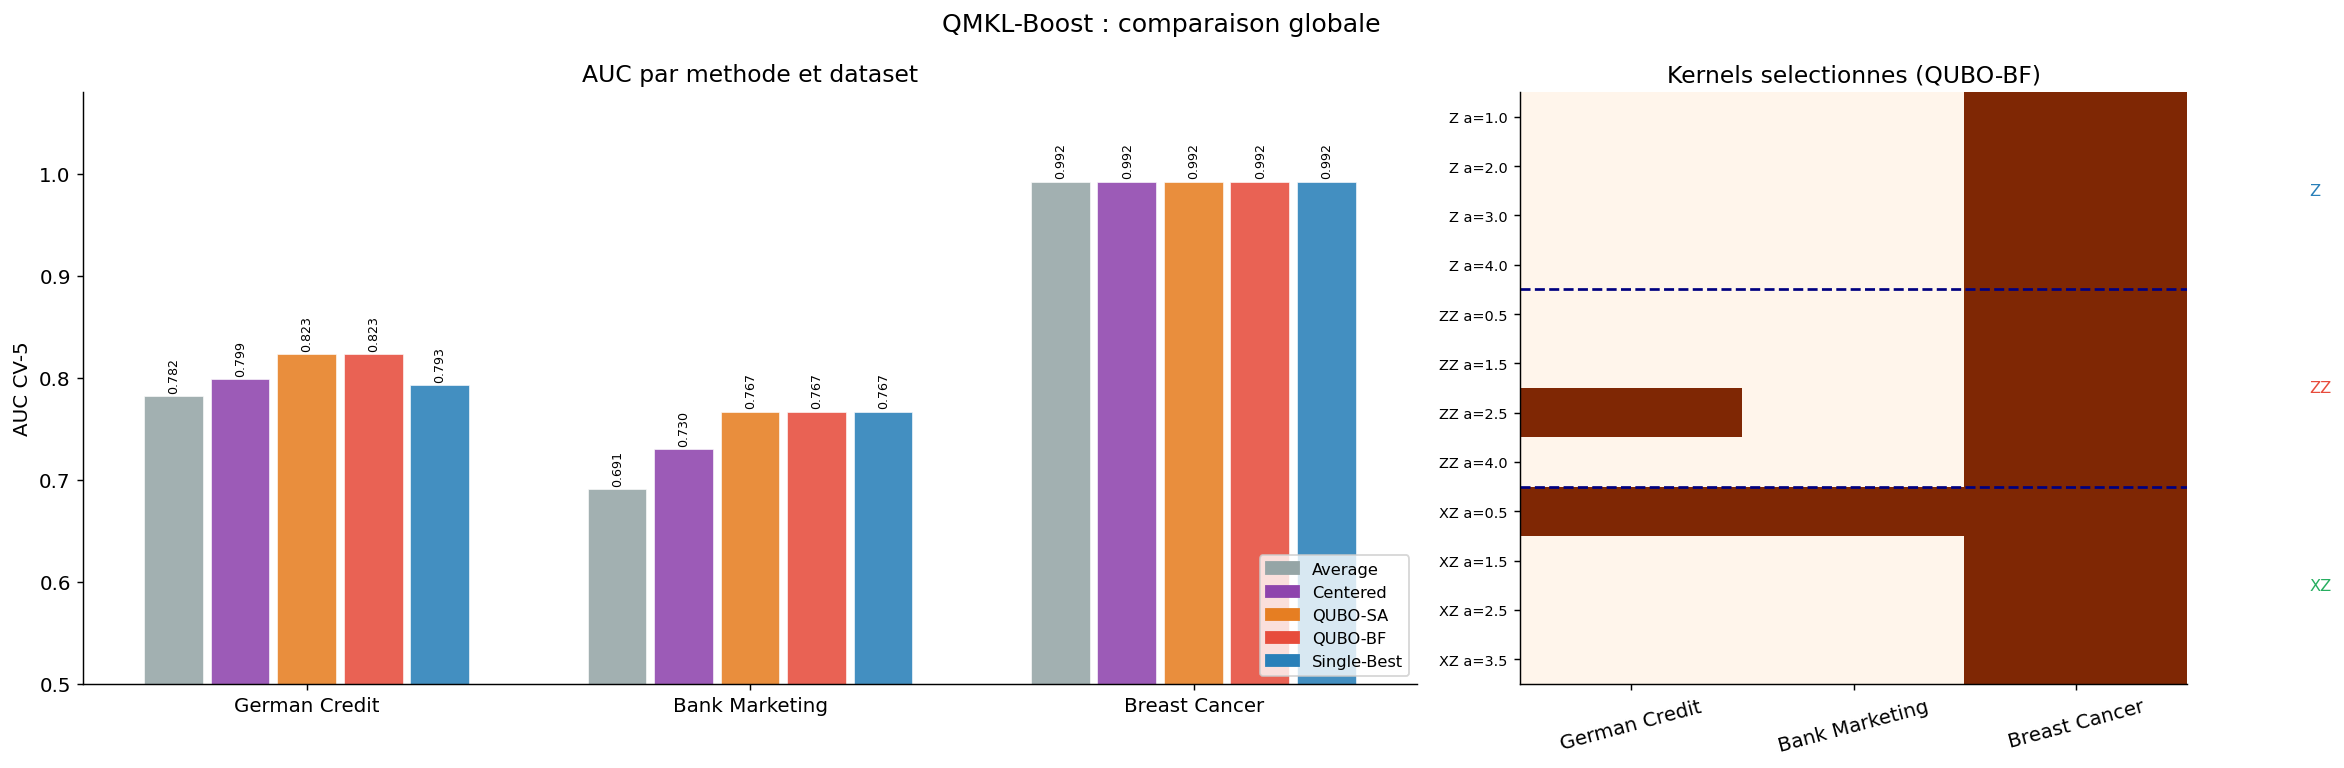

Figure 3 : 19_F3_comparison.png


In [8]:
n_ds  = len(DATASETS)
n_met = len(METHODS_ORDER)
x     = np.arange(n_ds)
width = 0.15

fig, axes = plt.subplots(1, 2, figsize=(18, 6),
                         gridspec_kw={'width_ratios': [2, 1]})
fig.suptitle('QMKL-Boost : comparaison globale', fontsize=14)

# Barplot AUC
ax = axes[0]
for i, meth in enumerate(METHODS_ORDER):
    aucs = [comparison[ds][meth]['auc'] for ds, _ in DATASETS]
    offset = (i - n_met / 2.0 + 0.5) * width
    bars = ax.bar(x + offset, aucs, width=width*0.9,
                  color=METHOD_COLORS[meth], label=meth,
                  alpha=0.88, edgecolor='white')
    for bar, auc in zip(bars, aucs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                '%.3f' % auc, ha='center', va='bottom', fontsize=7, rotation=90)
ax.set_xticks(x)
ax.set_xticklabels([ds_label for _, ds_label in DATASETS])
ax.set_ylabel('AUC CV-5')
ax.set_ylim(0.5, 1.08)
ax.set_title('AUC par methode et dataset')
patches = [mpatches.Patch(color=METHOD_COLORS[m], label=m) for m in METHODS_ORDER]
ax.legend(handles=patches, fontsize=9, loc='lower right')

# Heatmap selection QUBO-BF
ax = axes[1]
sel_mat = np.zeros((M, n_ds))
for col, (ds_name, _) in enumerate(DATASETS):
    for m in comparison[ds_name]['QUBO-BF'].get('sel', []):
        sel_mat[m, col] = 1.0
ax.imshow(sel_mat, aspect='auto', cmap='Oranges', vmin=0, vmax=1)
ax.set_xticks(range(n_ds))
ax.set_xticklabels([ds_label for _, ds_label in DATASETS], rotation=15)
ax.set_yticks(range(M))
ax.set_yticklabels(KNAMES, fontsize=8)
ax.set_title('Kernels selectionnes (QUBO-BF)')
for sep in [3.5, 7.5]:
    ax.axhline(sep, color='navy', lw=1.5, ls='--')
for y_pos, fname in zip([1.5, 5.5, 9.5], ['Z', 'ZZ', 'XZ']):
    ax.text(n_ds + 0.05, y_pos, fname, fontsize=9,
            va='center', color=FAMILY_COLORS[fname])

plt.tight_layout()
plt.savefig(OUT / '19_F3_comparison.png', dpi=150)
plt.show()
print('Figure 3 : 19_F3_comparison.png')

In [9]:
print('=' * 68)
print(' SYNTHESE -- QMKL-Boost : QUBO comme selecteur de kernels')
print('=' * 68)
print()
print('[Configuration]')
print('  M=%d kernels (Z x4, ZZ x4, XZ x4)  N=%d  Q=%d' % (M, N_SAMPLES, Q))
print('  Brute-force : %d sous-ensembles' % (2**M - 1))

for ds_name, ds_label in DATASETS:
    print()
    print('[%s]' % ds_label)
    comp     = comparison[ds_name]
    lam_res  = lambda_auc[ds_name]
    lam_star = max(lam_res, key=lambda l: lam_res[l]['auc'])
    auc_avg  = comp['Average']['auc']
    for meth in METHODS_ORDER:
        r     = comp[meth]
        delta = r['auc'] - auc_avg
        sel   = [KNAMES[i] for i in r.get('sel', [])] if 'sel' in r else []
        print('  %-14s: AUC=%.4f (d_avg=%+.4f)  n=%d/%d  %s' % (
            meth, r['auc'], delta, r['n_sel'], M, sel))

print()
print('[Interpretation]')
for ds_name, ds_label in DATASETS:
    lam_res  = lambda_auc[ds_name]
    lam_star = max(lam_res, key=lambda l: lam_res[l]['auc'])
    res      = comparison[ds_name]['QUBO-BF']
    sel_n    = [KNAMES[i] for i in res.get('sel', [])]
    fams     = sorted(set(n.split()[0] for n in sel_n))
    print('  %s: lambda*=%.2f  k=%d  familles=%s  kernels=%s' % (
        ds_label, lam_star, res['n_sel'], fams, sel_n))

print()
print('Figures : 19_F1_kernel_metrics.png  19_F2_lambda_sweep.png  19_F3_comparison.png')
print('=' * 68)

 SYNTHESE -- QMKL-Boost : QUBO comme selecteur de kernels

[Configuration]
  M=12 kernels (Z x4, ZZ x4, XZ x4)  N=150  Q=6
  Brute-force : 4095 sous-ensembles

[German Credit]
  Average       : AUC=0.7820 (d_avg=+0.0000)  n=12/12  []
  Centered      : AUC=0.7989 (d_avg=+0.0169)  n=5/12  []
  QUBO-SA       : AUC=0.8233 (d_avg=+0.0413)  n=2/12  ['ZZ a=2.5', 'XZ a=0.5']
  QUBO-BF       : AUC=0.8233 (d_avg=+0.0413)  n=2/12  ['ZZ a=2.5', 'XZ a=0.5']
  Single-Best   : AUC=0.7926 (d_avg=+0.0106)  n=1/12  ['ZZ a=2.5']

[Bank Marketing]
  Average       : AUC=0.6906 (d_avg=+0.0000)  n=12/12  []
  Centered      : AUC=0.7304 (d_avg=+0.0398)  n=3/12  []
  QUBO-SA       : AUC=0.7669 (d_avg=+0.0763)  n=1/12  ['XZ a=0.5']
  QUBO-BF       : AUC=0.7669 (d_avg=+0.0763)  n=1/12  ['XZ a=0.5']
  Single-Best   : AUC=0.7669 (d_avg=+0.0763)  n=1/12  ['XZ a=0.5']

[Breast Cancer]
  Average       : AUC=0.9923 (d_avg=+0.0000)  n=12/12  []
  Centered      : AUC=0.9924 (d_avg=+0.0000)  n=3/12  []
  QUBO-SA       : 